Import CSV Data Rows

In [49]:
import pandas as pd
import numpy as np

df=pd.read_csv(r"C:\xampp816\htdocs\personal-dev\py-ds\numpy-pandas\data_analysis_mobile_dataset\mobile.csv", encoding="ISO-8859-1")
print(df.dtypes)
print(df)

Company Name                 object
Model Name                   object
Mobile Weight                object
RAM                          object
Front Camera                 object
Back Camera                  object
Processor                    object
Battery Capacity             object
Screen Size                  object
Launched Price (Pakistan)    object
Launched Price (India)       object
Launched Price (China)       object
Launched Price (USA)         object
Launched Price (Dubai)       object
Launched Year                 int64
dtype: object
    Company Name            Model Name Mobile Weight   RAM     Front Camera  \
0          Apple       iPhone 16 128GB          174g   6GB             12MP   
1          Apple       iPhone 16 256GB          174g   6GB             12MP   
2          Apple       iPhone 16 512GB          174g   6GB             12MP   
3          Apple  iPhone 16 Plus 128GB          203g   6GB             12MP   
4          Apple  iPhone 16 Plus 256GB          203

find and Remove Null Rows

In [50]:
# df.isna() # true false table
df.isna().sum() # sum of all true in each column
# df.dropna().isna().sum()
# df = df.dropna()
df.sum()

Company Name                 AppleAppleAppleAppleAppleAppleAppleAppleAppleA...
Model Name                   iPhone 16 128GBiPhone 16 256GBiPhone 16 512GBi...
Mobile Weight                174g174g174g203g203g203g206g206g206g221g221g22...
RAM                          6GB6GB6GB6GB6GB6GB6GB8GB8GB6GB8GB8GB6GB6GB6GB6...
Front Camera                 12MP12MP12MP12MP12MP12MP12MP / 4K12MP / 4K12MP...
Back Camera                  48MP48MP48MP48MP48MP48MP50MP + 12MP50MP + 12MP...
Processor                    A17 BionicA17 BionicA17 BionicA17 BionicA17 Bi...
Battery Capacity             3,600mAh3,600mAh3,600mAh4,200mAh4,200mAh4,200m...
Screen Size                  6.1 inches6.1 inches6.1 inches6.7 inches6.7 in...
Launched Price (Pakistan)    PKR 224,999PKR 234,999PKR 244,999PKR 249,999PK...
Launched Price (India)       INR 79,999INR 84,999INR 89,999INR 89,999INR 94...
Launched Price (China)       CNY 5,799CNY 6,099CNY 6,499CNY 6,199CNY 6,499C...
Launched Price (USA)         USD 799USD 849USD 899US

Find and Remove Duplicated Rows

In [51]:
df.duplicated().sum()
df.value_counts()
df.drop_duplicates(inplace=True)

Reset Index

In [52]:
df.reset_index(drop=True, inplace=True)

Clean Columns

In [53]:
df

,Company Name,Model Name,Mobile Weight,RAM,Front Camera,Back Camera,Processor,Battery Capacity,Screen Size,Launched Price (Pakistan),Launched Price (India),Launched Price (China),Launched Price (USA),Launched Price (Dubai),Launched Year
0,Apple,iPhone 16 128GB,174g,6GB,12MP,48MP,A17 Bionic,"3,600mAh",6.1 inches,"PKR 224,999","INR 79,999","CNY 5,799",USD 799,"AED 2,799",2024
1,Apple,iPhone 16 256GB,174g,6GB,12MP,48MP,A17 Bionic,"3,600mAh",6.1 inches,"PKR 234,999","INR 84,999","CNY 6,099",USD 849,"AED 2,999",2024
2,Apple,iPhone 16 512GB,174g,6GB,12MP,48MP,A17 Bionic,"3,600mAh",6.1 inches,"PKR 244,999","INR 89,999","CNY 6,499",USD 899,"AED 3,199",2024
3,Apple,iPhone 16 Plus 128GB,203g,6GB,12MP,48MP,A17 Bionic,"4,200mAh",6.7 inches,"PKR 249,999","INR 89,999","CNY 6,199",USD 899,"AED 3,199",2024
4,Apple,iPhone 16 Plus 256GB,203g,6GB,12MP,48MP,A17 Bionic,"4,200mAh",6.7 inches,"PKR 259,999","INR 94,999","CNY 6,499",USD 949,"AED 3,399",2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
910,Poco,Pad 5G 128GB,571g,8GB,8MP,8MP,Snapdragon 7s Gen 2,"10,000mAh",12.1 inches,"PKR 66,220","INR 23,999","CNY 2,099",USD 280,"AED 1,029",2024
911,Poco,Pad 5G 256GB,571g,8GB,8MP,8MP,Snapdragon 7s Gen 2,"10,000mAh",12.1 inches,"PKR 71,220","INR 25,999","CNY 2,299",USD 300,"AED 1,099",2024
912,Samsung,Galaxy Z Fold6 256GB,239g,12GB,"10MP, 4MP (UDC)",50MP,Snapdragon 8 Gen 3,4400mAh,7.6 inches,"PKR 604,999","INR 164,999","¥13,999","USD 1,899","AED 7,199",2024
913,Samsung,Galaxy Z Fold6 512GB,239g,12GB,"10MP, 4MP (UDC)",50MP,Snapdragon 8 Gen 3,4400mAh,7.6 inches,"PKR 544,999","INR 176,999","CNY 15,999",USD 1719,"AED 7,699",2024


In [ ]:
import re

df1 = pd.DataFrame()
def extract_numeric(value):
    # numeric_values = re.findall(r'\d+\.?\d*', str(value))
    cleaned_value = re.sub(r'[^0-9.]', '', str(value))
    return float(cleaned_value) if cleaned_value else None
numeric_columns = [
                    'Mobile Weight',
                    'RAM',
                    'Front Camera',
                    'Back Camera',
                    'Battery Capacity',
                    'Launched Price (Pakistan)',
                    'Launched Price (India)',
                    'Launched Price (China)',
                    'Launched Price (USA)',
                    'Launched Price (Dubai)',
                ]
for col in df:
    if col in numeric_columns:
        new_col_name = f"{col.lower().replace(' ', '_')}_num"
        df1[new_col_name] = df[col].apply(extract_numeric)
    else:
        df1[col] = df[col]
df1.columns = [
    'company_name', 'model_name', 'mobile_weight_num', 'ram_num', 
    'front_camera_num', 'back_camera_num', 'processor', 'battery_capacity_num', 
    'screen_size', 'launched_price_(pakistan)_num', 'launched_price_(india)_num', 
    'launched_price_(china)_num', 'launched_price_(usa)_num', 
    'launched_price_(dubai)_num', 'launched_year'
]
df1

,company_name,model_name,mobile_weight_num,ram_num,front_camera_num,back_camera_num,processor,battery_capacity_num,screen_size,launched_price_(pakistan)_num,launched_price_(india)_num,launched_price_(china)_num,launched_price_(usa)_num,launched_price_(dubai)_num,launched_year
0,Apple,iPhone 16 128GB,174.0,6.0,12.0,48.0,A17 Bionic,3600.0,6.1 inches,224999.0,79999.0,5799.0,799.0,2799.0,2024
1,Apple,iPhone 16 256GB,174.0,6.0,12.0,48.0,A17 Bionic,3600.0,6.1 inches,234999.0,84999.0,6099.0,849.0,2999.0,2024
2,Apple,iPhone 16 512GB,174.0,6.0,12.0,48.0,A17 Bionic,3600.0,6.1 inches,244999.0,89999.0,6499.0,899.0,3199.0,2024
3,Apple,iPhone 16 Plus 128GB,203.0,6.0,12.0,48.0,A17 Bionic,4200.0,6.7 inches,249999.0,89999.0,6199.0,899.0,3199.0,2024
4,Apple,iPhone 16 Plus 256GB,203.0,6.0,12.0,48.0,A17 Bionic,4200.0,6.7 inches,259999.0,94999.0,6499.0,949.0,3399.0,2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
910,Poco,Pad 5G 128GB,571.0,8.0,8.0,8.0,Snapdragon 7s Gen 2,10000.0,12.1 inches,66220.0,23999.0,2099.0,280.0,1029.0,2024
911,Poco,Pad 5G 256GB,571.0,8.0,8.0,8.0,Snapdragon 7s Gen 2,10000.0,12.1 inches,71220.0,25999.0,2299.0,300.0,1099.0,2024
912,Samsung,Galaxy Z Fold6 256GB,239.0,12.0,104.0,50.0,Snapdragon 8 Gen 3,4400.0,7.6 inches,604999.0,164999.0,13999.0,1899.0,7199.0,2024
913,Samsung,Galaxy Z Fold6 512GB,239.0,12.0,104.0,50.0,Snapdragon 8 Gen 3,4400.0,7.6 inches,544999.0,176999.0,15999.0,1719.0,7699.0,2024


extract capacity in a new column from model_name

In [ ]:
import re

def extract_capacity(model_name):
    capacity_match = re.search(r'(\d+)(GB|TB)', model_name)
    if capacity_match:
        capacity = int(capacity_match.group(1))
        unit = capacity_match.group(2)
        if unit == 'TB':
            capacity *= 1024
        return capacity
    return None
if 'capacity_gb' not in df1.columns:
    df1.insert(df1.columns.get_loc('model_name') + 1, 'capacity_gb', df1['model_name'].apply(extract_capacity))
df1

,company_name,model_name,capacity_gb,mobile_weight_num,ram_num,front_camera_num,back_camera_num,processor,battery_capacity_num,screen_size,launched_price_(pakistan)_num,launched_price_(india)_num,launched_price_(china)_num,launched_price_(usa)_num,launched_price_(dubai)_num,launched_year
0,Apple,iPhone 16 128GB,128.0,174.0,6.0,12.0,48.0,A17 Bionic,3600.0,6.1 inches,224999.0,79999.0,5799.0,799.0,2799.0,2024
1,Apple,iPhone 16 256GB,256.0,174.0,6.0,12.0,48.0,A17 Bionic,3600.0,6.1 inches,234999.0,84999.0,6099.0,849.0,2999.0,2024
2,Apple,iPhone 16 512GB,512.0,174.0,6.0,12.0,48.0,A17 Bionic,3600.0,6.1 inches,244999.0,89999.0,6499.0,899.0,3199.0,2024
3,Apple,iPhone 16 Plus 128GB,128.0,203.0,6.0,12.0,48.0,A17 Bionic,4200.0,6.7 inches,249999.0,89999.0,6199.0,899.0,3199.0,2024
4,Apple,iPhone 16 Plus 256GB,256.0,203.0,6.0,12.0,48.0,A17 Bionic,4200.0,6.7 inches,259999.0,94999.0,6499.0,949.0,3399.0,2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
910,Poco,Pad 5G 128GB,128.0,571.0,8.0,8.0,8.0,Snapdragon 7s Gen 2,10000.0,12.1 inches,66220.0,23999.0,2099.0,280.0,1029.0,2024
911,Poco,Pad 5G 256GB,256.0,571.0,8.0,8.0,8.0,Snapdragon 7s Gen 2,10000.0,12.1 inches,71220.0,25999.0,2299.0,300.0,1099.0,2024
912,Samsung,Galaxy Z Fold6 256GB,256.0,239.0,12.0,104.0,50.0,Snapdragon 8 Gen 3,4400.0,7.6 inches,604999.0,164999.0,13999.0,1899.0,7199.0,2024
913,Samsung,Galaxy Z Fold6 512GB,512.0,239.0,12.0,104.0,50.0,Snapdragon 8 Gen 3,4400.0,7.6 inches,544999.0,176999.0,15999.0,1719.0,7699.0,2024


In [70]:
if df1['screen_size'].dtype == 'object':
    df1['screen_size'] = df1['screen_size'].str.extract(r'(\d+\.?\d*)').astype(float)
df1.dtypes

company_name                      object
model_name                        object
capacity_gb                      float64
mobile_weight_num                float64
ram_num                          float64
front_camera_num                 float64
back_camera_num                  float64
processor                         object
battery_capacity_num             float64
screen_size                      float64
launched_price_(pakistan)_num    float64
launched_price_(india)_num       float64
launched_price_(china)_num       float64
launched_price_(usa)_num         float64
launched_price_(dubai)_num       float64
launched_year                      int64
dtype: object

In [ ]:
# pd.to_datetime(df1['launched_year'], format="%Y")

0     2024-01-01
1     2024-01-01
2     2024-01-01
3     2024-01-01
4     2024-01-01
         ...    
910   2024-01-01
911   2024-01-01
912   2024-01-01
913   2024-01-01
914   2024-01-01
Name: launched_year, Length: 915, dtype: datetime64[ns]

In [89]:
df1['launched_price_(india)_num'].describe().round(2)

count       915.00
mean      51070.46
std       41104.09
min        5999.00
25%       19999.00
50%       35990.00
75%       74999.00
max      274999.00
Name: launched_price_(india)_num, dtype: float64

In [92]:
import pandas as pd

bins = [0, 20000, 40000, 75000, 150000, float('inf')]
labels = ['Cheap', 'Affordable', 'Mid-Range', 'Expensive', 'Premium']

if 'price_category' not in df1.columns:
    df1.insert(df1.columns.get_loc('launched_price_(india)_num') - 1, 'price_category', pd.cut(df1['launched_price_(india)_num'], bins=bins, labels=labels))
df1

,company_name,model_name,capacity_gb,mobile_weight_num,ram_num,front_camera_num,back_camera_num,processor,battery_capacity_num,screen_size,price_category,launched_price_(pakistan)_num,launched_price_(india)_num,launched_price_(china)_num,launched_price_(usa)_num,launched_price_(dubai)_num,launched_year
0,Apple,iPhone 16 128GB,128.0,174.0,6.0,12.0,48.0,A17 Bionic,3600.0,6.1,Expensive,224999.0,79999.0,5799.0,799.0,2799.0,2024
1,Apple,iPhone 16 256GB,256.0,174.0,6.0,12.0,48.0,A17 Bionic,3600.0,6.1,Expensive,234999.0,84999.0,6099.0,849.0,2999.0,2024
2,Apple,iPhone 16 512GB,512.0,174.0,6.0,12.0,48.0,A17 Bionic,3600.0,6.1,Expensive,244999.0,89999.0,6499.0,899.0,3199.0,2024
3,Apple,iPhone 16 Plus 128GB,128.0,203.0,6.0,12.0,48.0,A17 Bionic,4200.0,6.7,Expensive,249999.0,89999.0,6199.0,899.0,3199.0,2024
4,Apple,iPhone 16 Plus 256GB,256.0,203.0,6.0,12.0,48.0,A17 Bionic,4200.0,6.7,Expensive,259999.0,94999.0,6499.0,949.0,3399.0,2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
910,Poco,Pad 5G 128GB,128.0,571.0,8.0,8.0,8.0,Snapdragon 7s Gen 2,10000.0,12.1,Affordable,66220.0,23999.0,2099.0,280.0,1029.0,2024
911,Poco,Pad 5G 256GB,256.0,571.0,8.0,8.0,8.0,Snapdragon 7s Gen 2,10000.0,12.1,Affordable,71220.0,25999.0,2299.0,300.0,1099.0,2024
912,Samsung,Galaxy Z Fold6 256GB,256.0,239.0,12.0,104.0,50.0,Snapdragon 8 Gen 3,4400.0,7.6,Premium,604999.0,164999.0,13999.0,1899.0,7199.0,2024
913,Samsung,Galaxy Z Fold6 512GB,512.0,239.0,12.0,104.0,50.0,Snapdragon 8 Gen 3,4400.0,7.6,Premium,544999.0,176999.0,15999.0,1719.0,7699.0,2024


In [98]:
df1['model_name'].unique()

array(['iPhone 16 128GB', 'iPhone 16 256GB', 'iPhone 16 512GB',
       'iPhone 16 Plus 128GB', 'iPhone 16 Plus 256GB',
       'iPhone 16 Plus 512GB', 'iPhone 16 Pro 128GB',
       'iPhone 16 Pro 256GB', 'iPhone 16 Pro 512GB',
       'iPhone 16 Pro Max 128GB', 'iPhone 16 Pro Max 256GB',
       'iPhone 16 Pro Max 512GB', 'iPhone 15 128GB', 'iPhone 15 256GB',
       'iPhone 15 512GB', 'iPhone 15 Plus 128GB', 'iPhone 15 Plus 256GB',
       'iPhone 15 Plus 512GB', 'iPhone 15 Pro 128GB',
       'iPhone 15 Pro 256GB', 'iPhone 15 Pro 512GB',
       'iPhone 15 Pro Max 128GB', 'iPhone 15 Pro Max 256GB',
       'iPhone 15 Pro Max 512GB', 'iPhone 14 128GB', 'iPhone 14 256GB',
       'iPhone 14 512GB', 'iPhone 14 Plus 128GB', 'iPhone 14 Plus 256GB',
       'iPhone 14 Plus 512GB', 'iPhone 14 Pro 128GB',
       'iPhone 14 Pro 256GB', 'iPhone 14 Pro 512GB',
       'iPhone 14 Pro Max 128GB', 'iPhone 14 Pro Max 256GB',
       'iPhone 14 Pro Max 512GB', 'iPhone 13 mini 128GB',
       'iPhone 13 mini 256G

In [108]:
import pandas as pd
import numpy as np

conditions = [
    df1['model_name'].str.contains('Fold', case=False, regex=False),
    (df1['screen_size'] >= 7) & df1['model_name'].str.contains('Pad', case=False, regex=False),
    df1['model_name'].str.contains('Flip', case=False, regex=False),
    True
]

choices = ['fold', 'tablet', 'flip', 'mobile']

if 'form_factor' not in df1.columns:
    df1.insert(df1.columns.get_loc('model_name') + 1, 'form_factor', pd.Series(np.select(conditions, choices, default='mobile')))
    df1['form_factor'] = pd.Categorical(df1['form_factor'], categories=['fold', 'tablet', 'fablet', 'flip', 'mobile'], ordered=False)
df1.dtypes


company_name                       object
model_name                         object
form_factor                      category
capacity_gb                       float64
mobile_weight_num                 float64
ram_num                           float64
front_camera_num                  float64
back_camera_num                   float64
processor                          object
battery_capacity_num              float64
screen_size                       float64
price_category                   category
launched_price_(pakistan)_num     float64
launched_price_(india)_num        float64
launched_price_(china)_num        float64
launched_price_(usa)_num          float64
launched_price_(dubai)_num        float64
launched_year                       int64
dtype: object

In [118]:
df1['processor'] = pd.Categorical(df1['processor'])
df1.dtypes

company_name                       object
model_name                         object
form_factor                      category
capacity_gb                       float64
mobile_weight_num                 float64
ram_num                           float64
front_camera_num                  float64
back_camera_num                   float64
processor                        category
battery_capacity_num              float64
screen_size                       float64
price_category                   category
launched_price_(pakistan)_num     float64
launched_price_(india)_num        float64
launched_price_(china)_num        float64
launched_price_(usa)_num          float64
launched_price_(dubai)_num        float64
launched_year                       int64
dtype: object

Analysis - Graphs

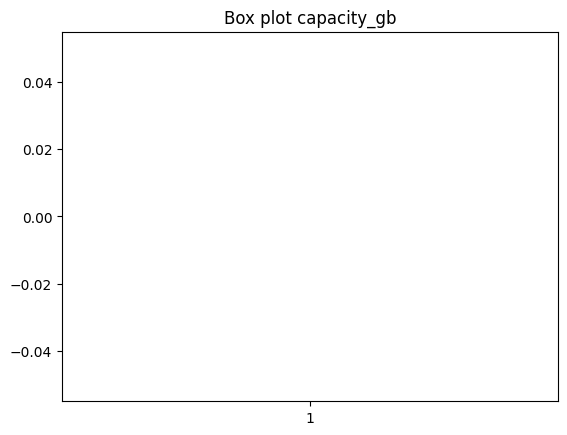

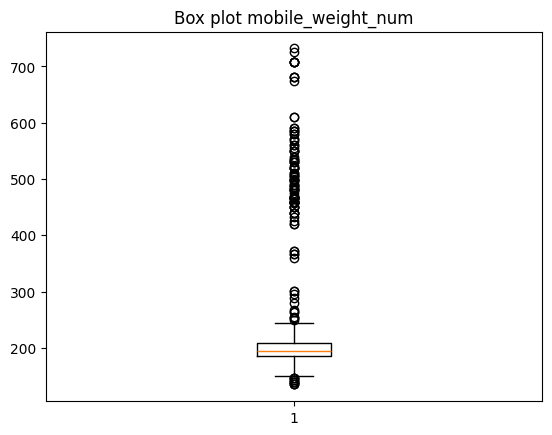

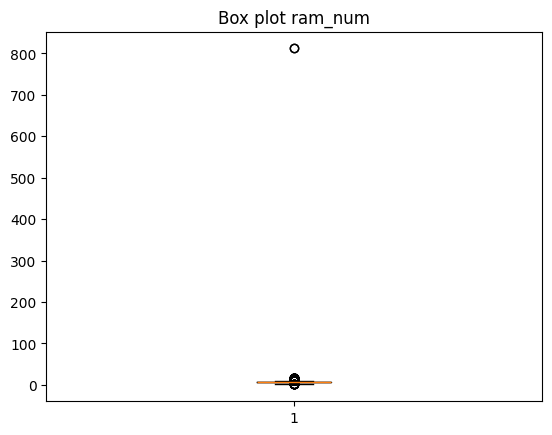

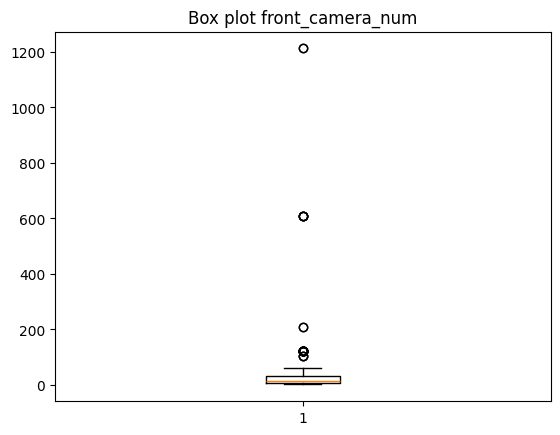

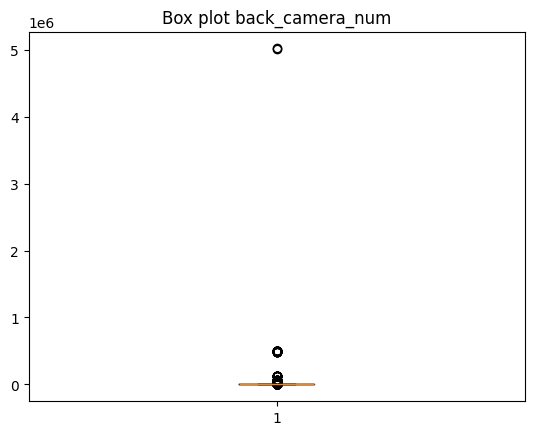

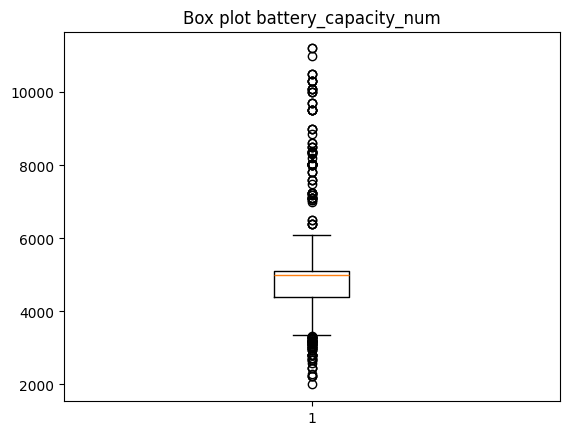

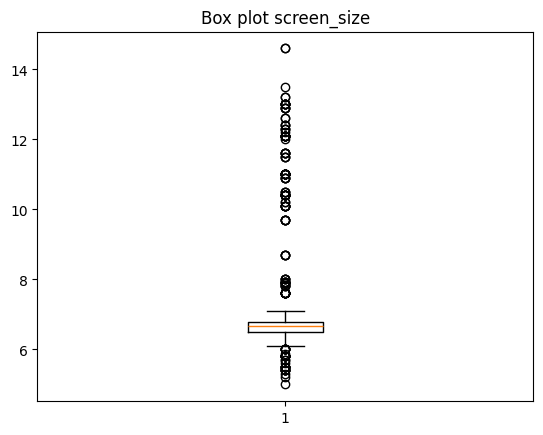

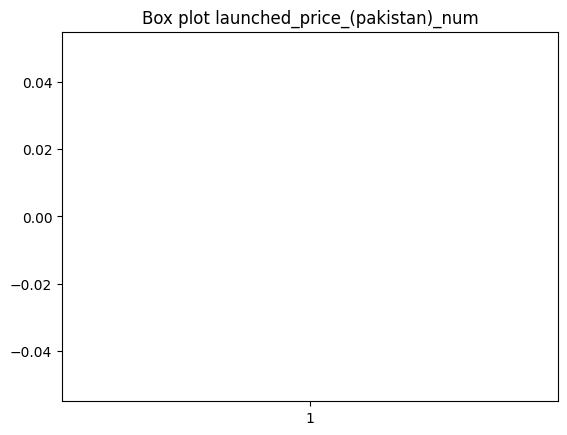

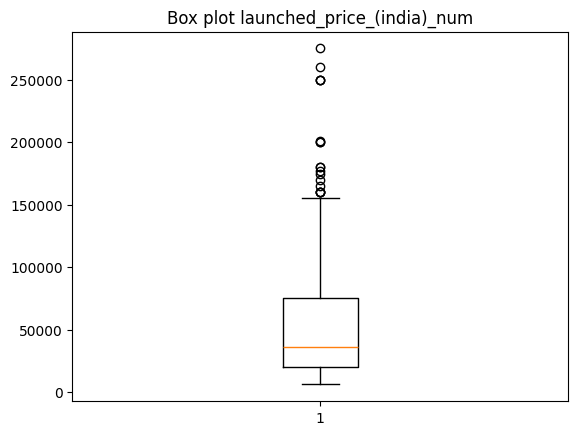

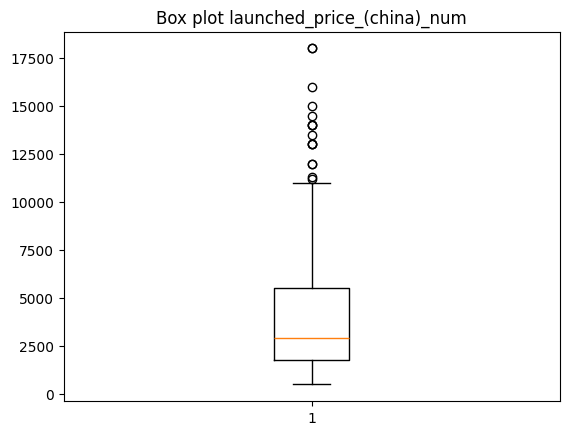

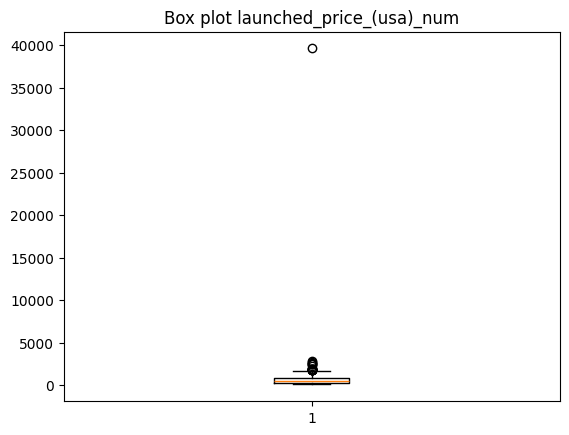

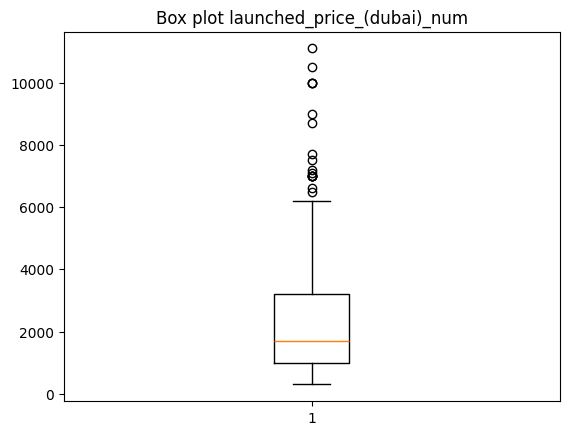

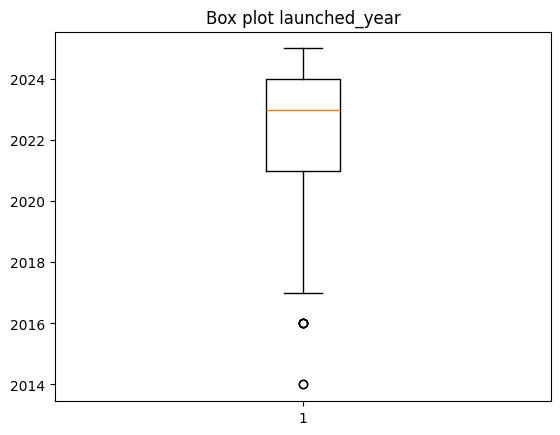

In [120]:
import matplotlib.pyplot as plt

for i in df1:
    if df1[i].dtype=='int64' or df1[i].dtype=='float':
        plt.boxplot(df1[i])
        plt.title(f'Box plot {i}')
        plt.show()

Bar graph analysis - categoical columns

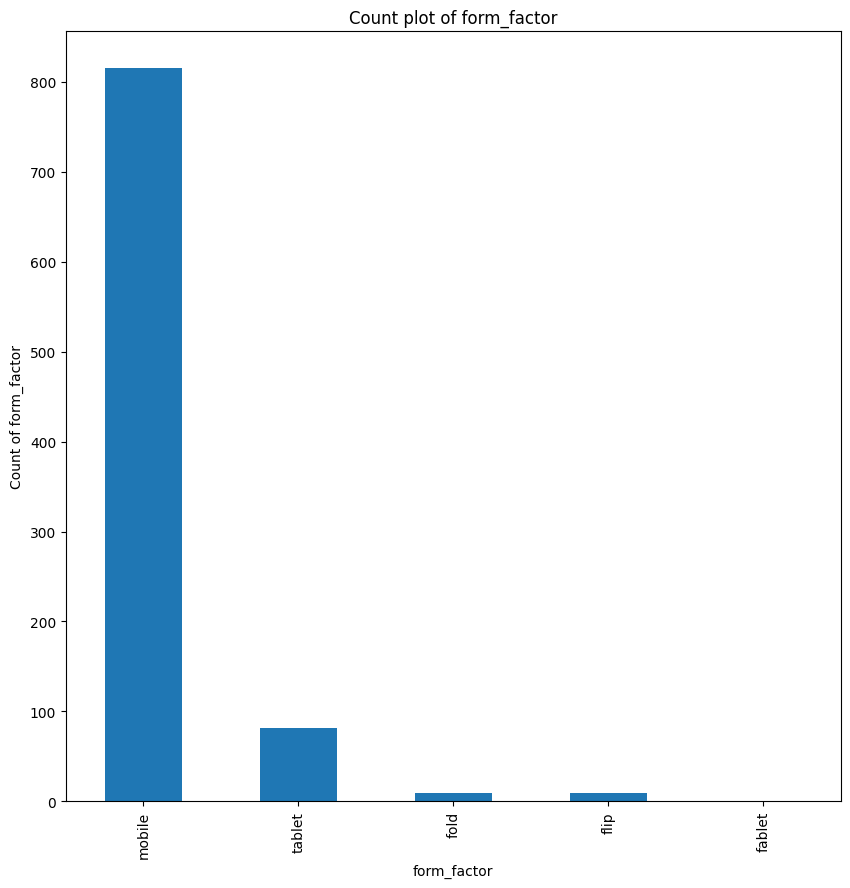

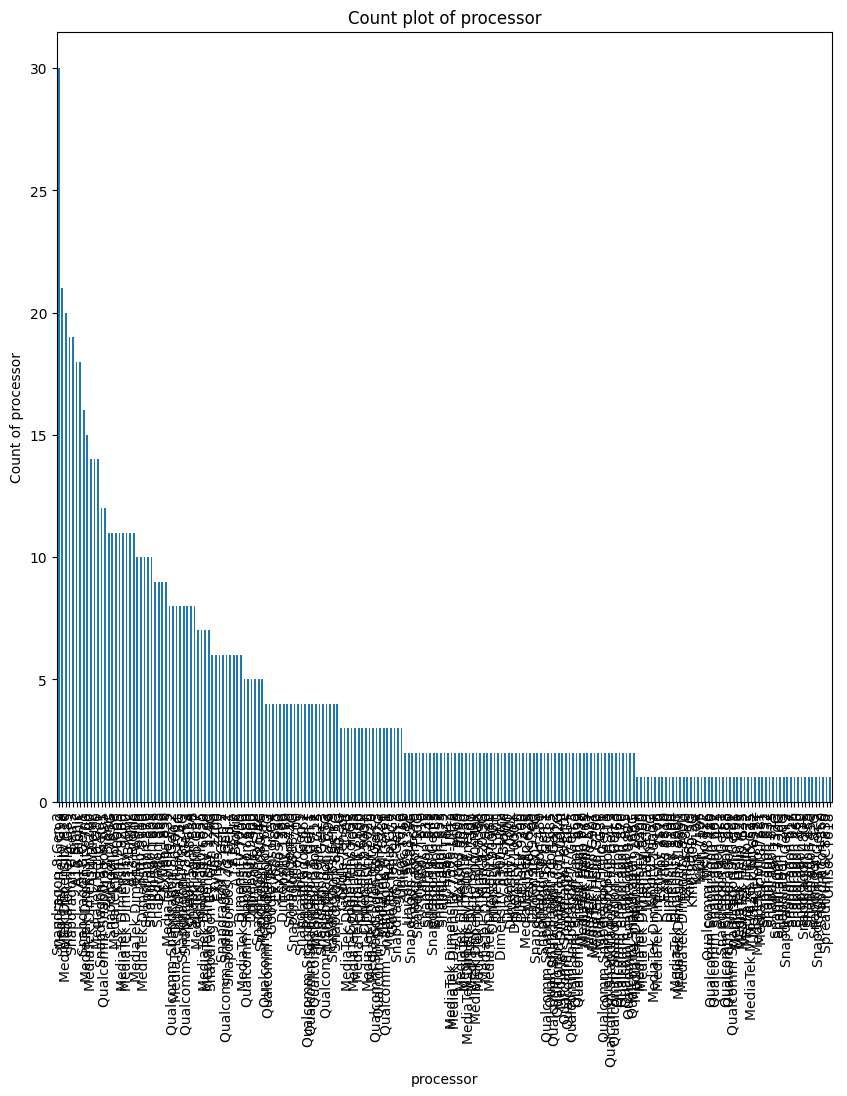

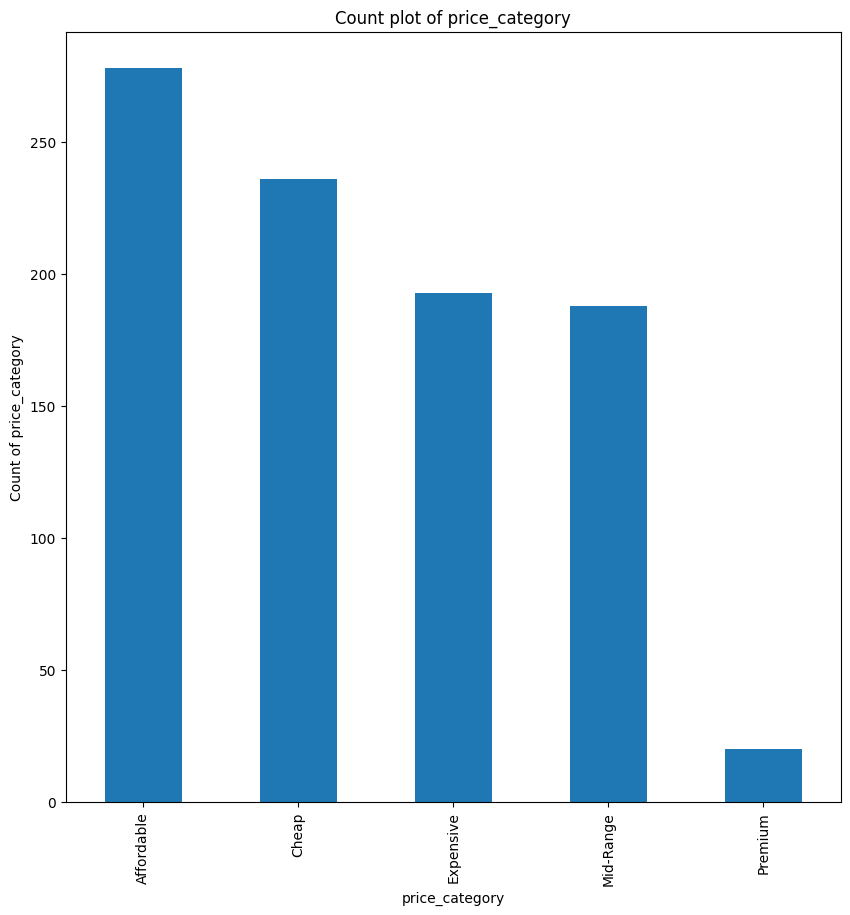

In [128]:
import matplotlib.pyplot as plt

for i in df1:
    if df1[i].dtype == 'category':
        value_counts = df1[i].value_counts()
        plt.figure(figsize=(10,10))
        if (value_counts > 10).any():  # Check if any count is greater than 20
            value_counts.plot(kind='bar')
            plt.title(f"Count plot of {i}")
            plt.xlabel(i)
            plt.ylabel(f'Count of {i}')
            plt.show()

In [133]:
df1.dtypes

company_name                       object
model_name                         object
form_factor                      category
capacity_gb                       float64
mobile_weight_num                 float64
ram_num                           float64
front_camera_num                  float64
back_camera_num                   float64
processor                        category
battery_capacity_num              float64
screen_size                       float64
price_category                   category
launched_price_(pakistan)_num     float64
launched_price_(india)_num        float64
launched_price_(china)_num        float64
launched_price_(usa)_num          float64
launched_price_(dubai)_num        float64
launched_year                       int64
dtype: object

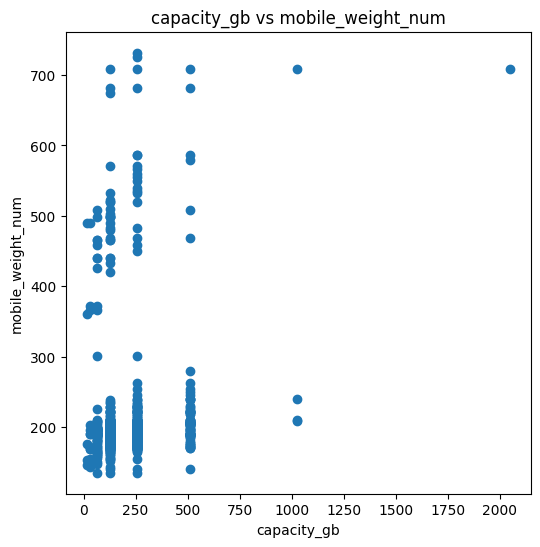

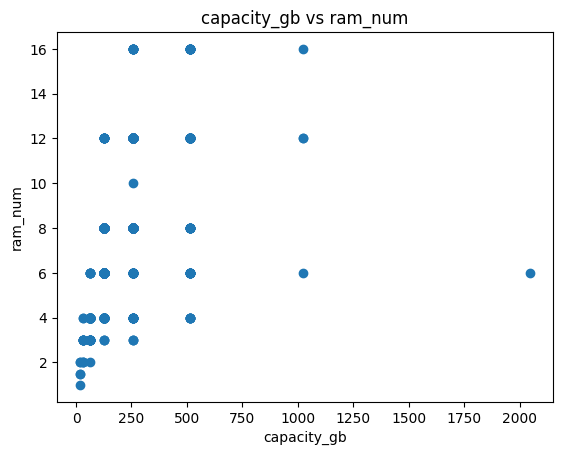

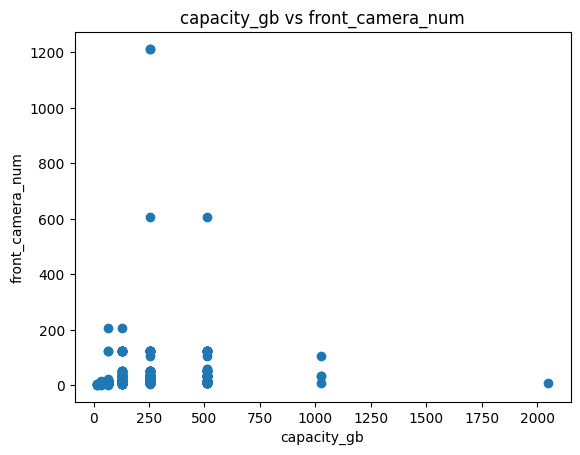

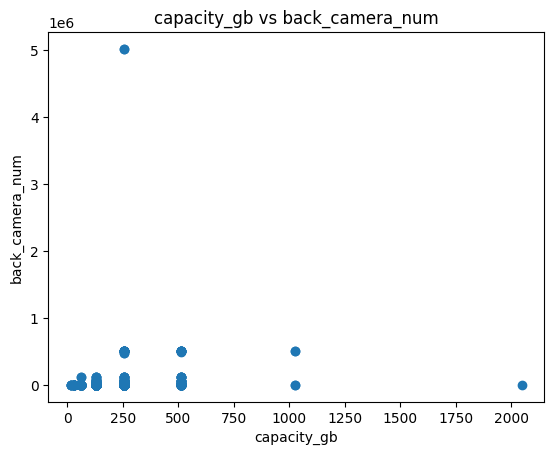

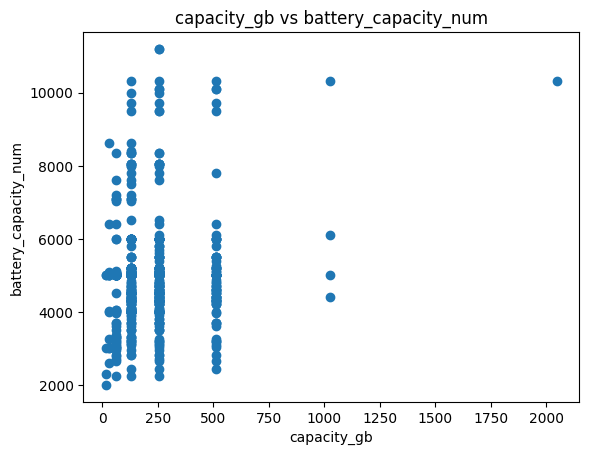

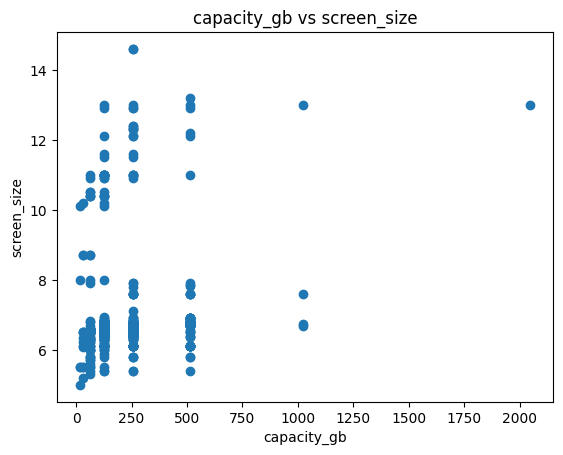

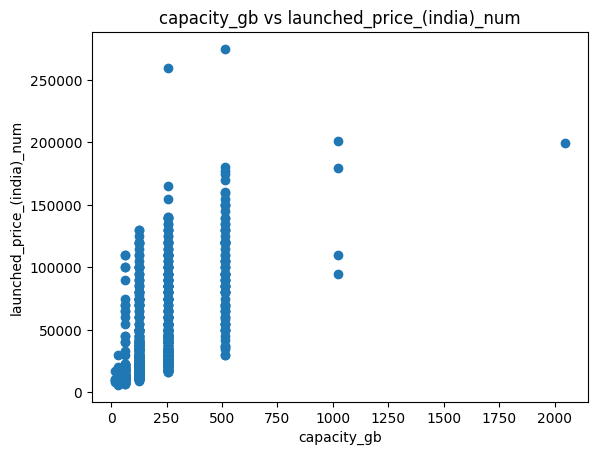

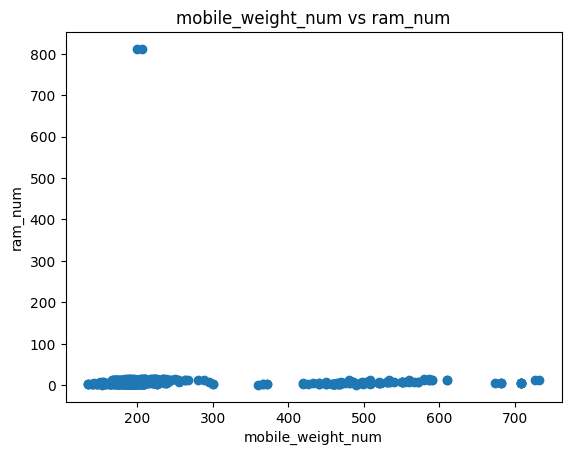

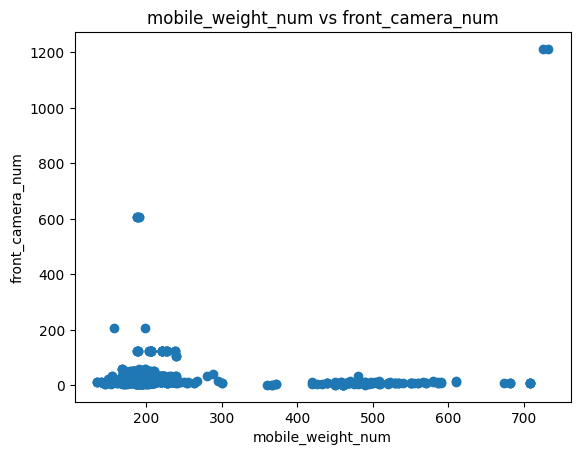

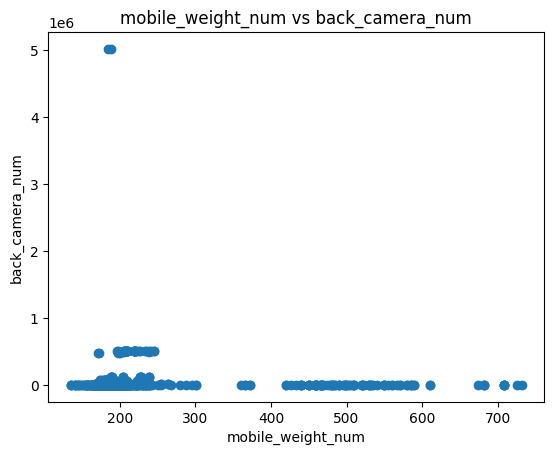

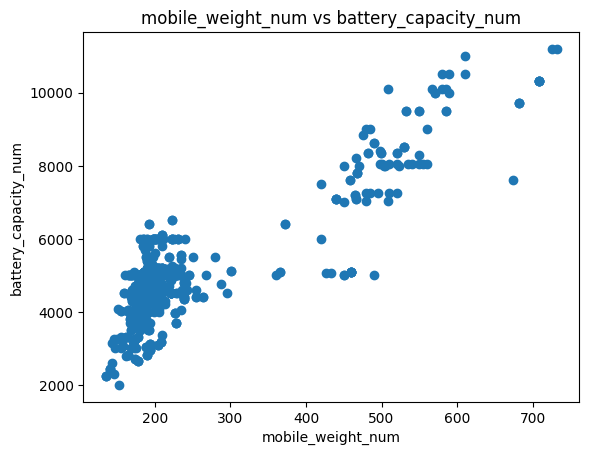

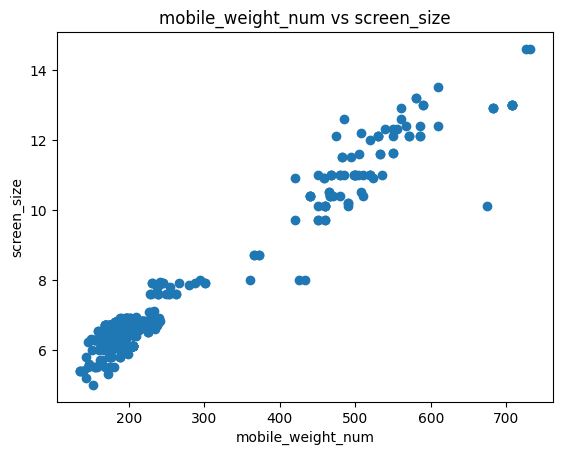

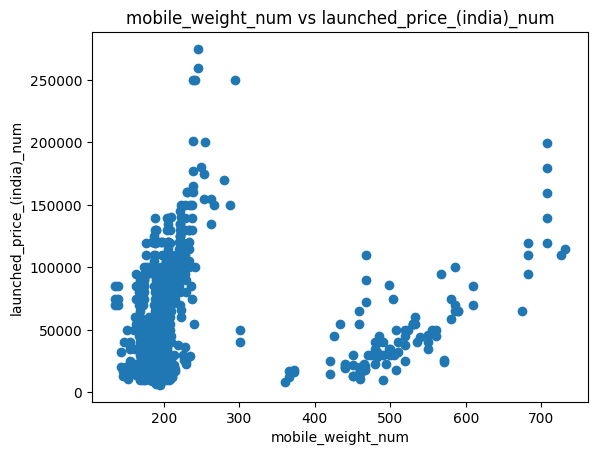

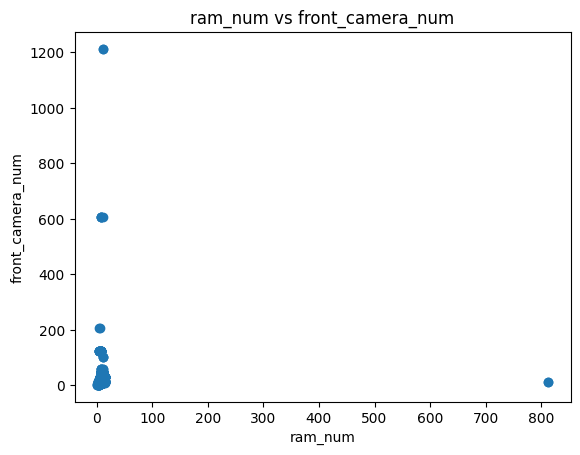

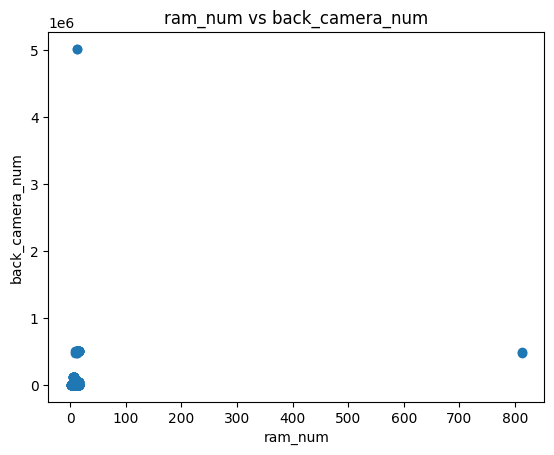

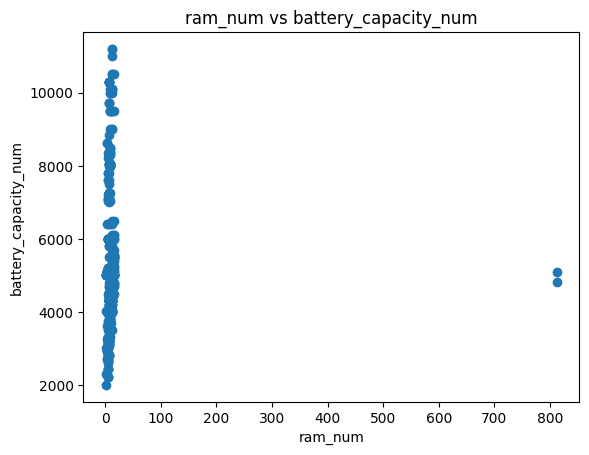

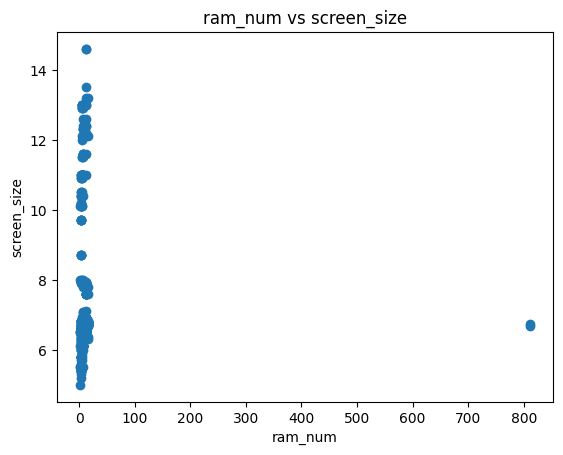

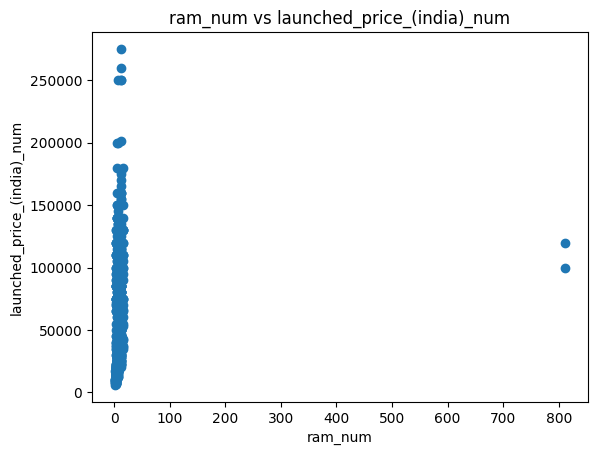

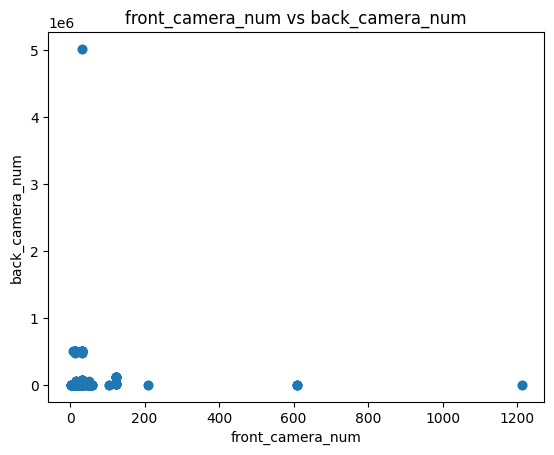

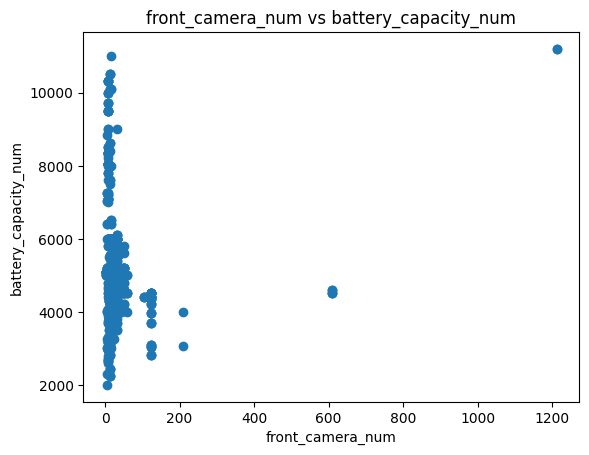

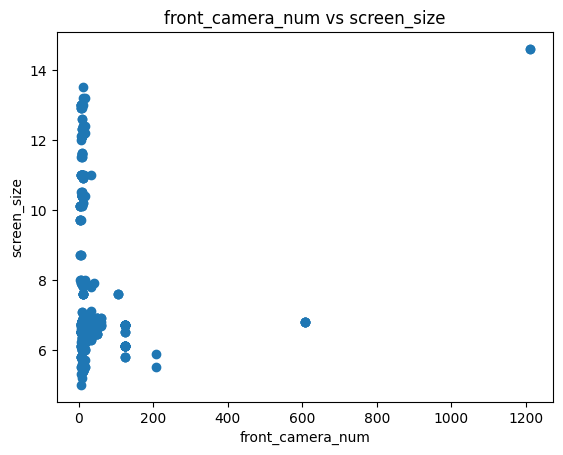

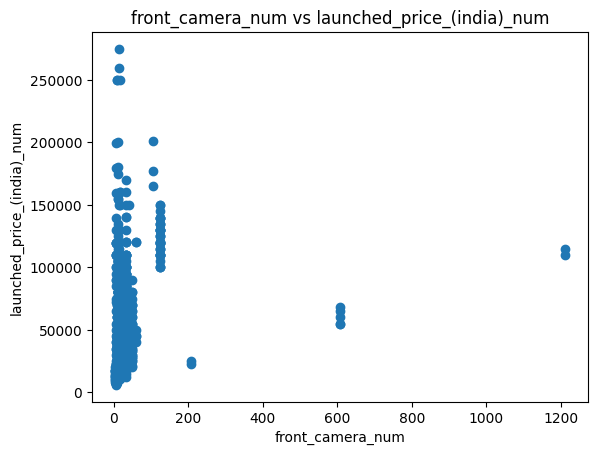

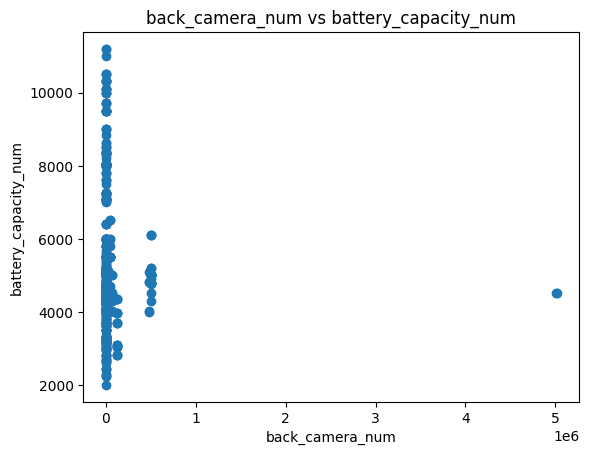

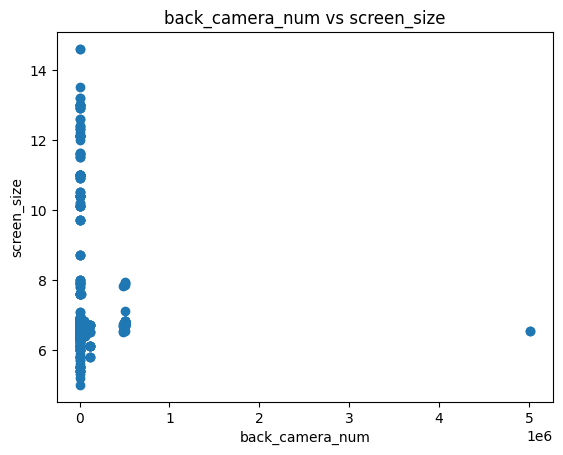

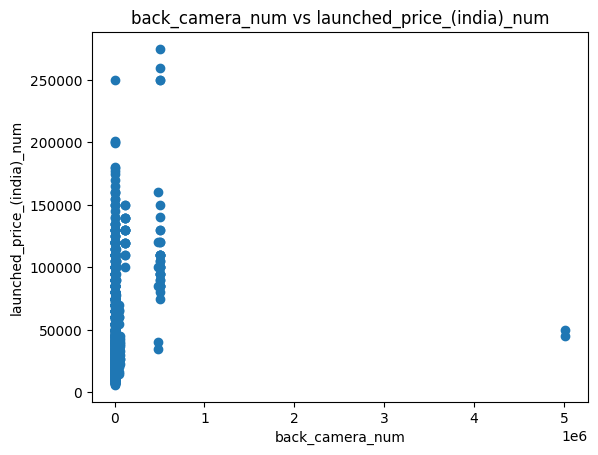

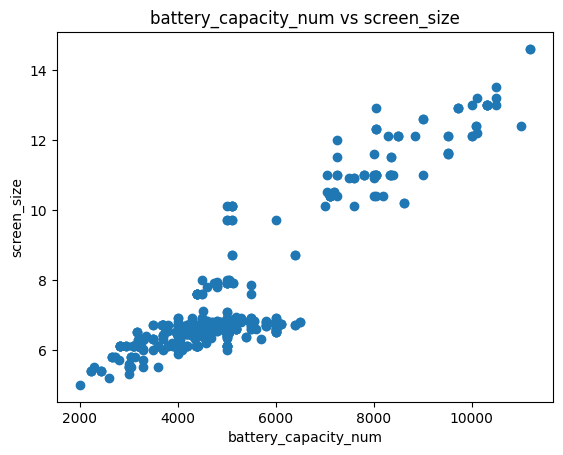

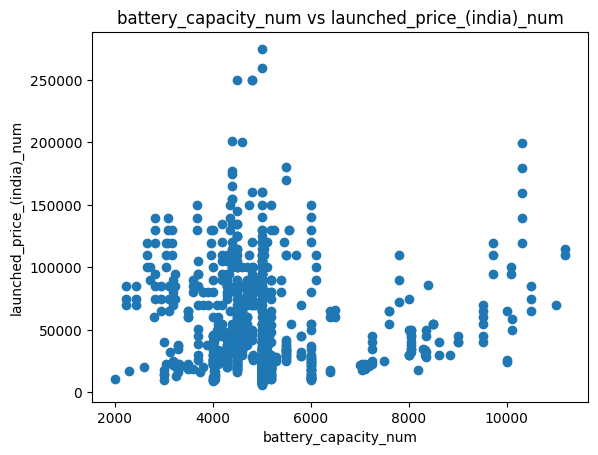

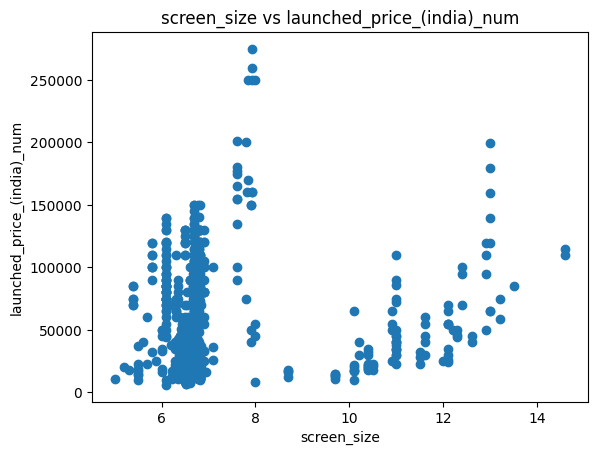

In [142]:
import matplotlib.pyplot as plt

columns = ['capacity_gb', 'mobile_weight_num', 'ram_num', 'front_camera_num', 'back_camera_num', 'battery_capacity_num', 'screen_size', 'launched_price_(india)_num']

plt.figure(figsize=(6, 6))

for i in range(len(columns)):
    for j in range(i + 1, len(columns)):
        plt.scatter(df1[columns[i]], df1[columns[j]])
        plt.xlabel(columns[i])
        plt.ylabel(columns[j])
        plt.title(f'{columns[i]} vs {columns[j]}')
        plt.show()

In [148]:
df1.dtypes

company_name                       object
model_name                         object
form_factor                      category
capacity_gb                       float64
mobile_weight_num                 float64
ram_num                           float64
front_camera_num                  float64
back_camera_num                   float64
processor                        category
battery_capacity_num              float64
screen_size                       float64
price_category                   category
launched_price_(pakistan)_num     float64
launched_price_(india)_num        float64
launched_price_(china)_num        float64
launched_price_(usa)_num          float64
launched_price_(dubai)_num        float64
launched_year                       int64
dtype: object

Seaborn - Heat Map

<Axes: >

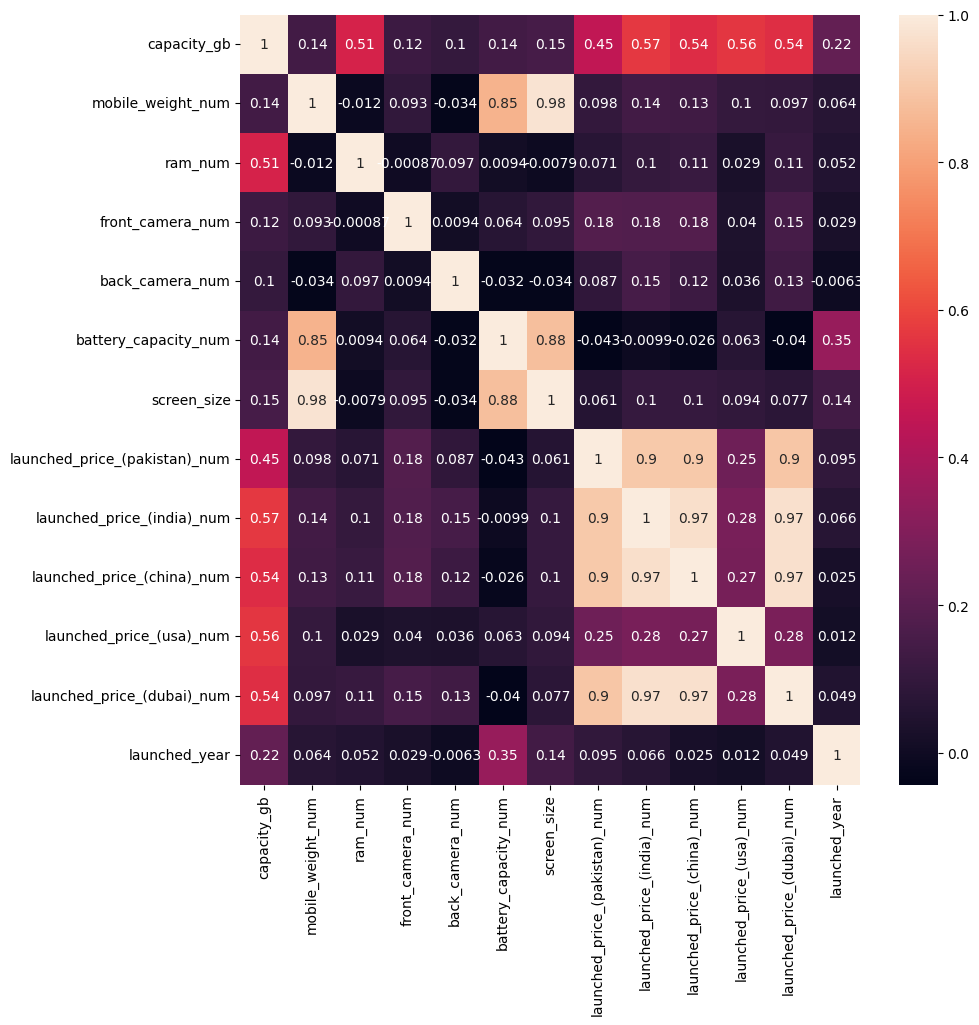

In [ ]:
import seaborn as sns

columns_to_include = ['columnA', 'columnB', 'columnC']
plt.figure(figsize=(10,10))
sns.heatmap(df1.corr(numeric_only=True), annot=True)